# Exploración inicial del CSV crudo de OPSD


Esta notebook revisa la estructura del archivo `data/raw/time_series_60min_singleindex.csv`, identifica las columnas de demanda real que terminan en `_load_actual_entsoe_transparency` y resume su cobertura, nulos, duplicados y comportamiento horario para decidir qué países se podrán transformar después al contrato `timestamp,y`.

## Plan de implementación

1. Explorar el CSV crudo sin modificarlo para confirmar columnas, fechas, volumen y variables de demanda real disponibles.
2. Documentar reglas de seleccion: usar `utc_timestamp` como tiempo y solo columnas terminadas en `_load_actual_entsoe_transparency`.
3. Evaluar calidad por país: cobertura temporal, cantidad de observaciones, porcentaje de nulos, duplicados y regularidad horaria.
4. Definir criterios para la preparación: países elegibles, tratamiento de nulos, orden temporal, zona horaria y nombres de salida.
5. Implementar una segunda notebook, `02_prepare_country_datasets.ipynb`, que exporte archivos `data/processed/{PAIS}.csv` con columnas `timestamp,y`.
6. Llevar las reglas estables a funciones del paquete `src/energy_forecast/data/` cuando la exploración y preparación ya estén validadas.

## Importaciones y rutas

Se importan las librerías necesarias y se resuelven rutas relativas desde la ubicación de la notebook hacia el archivo crudo esperado por el proyecto.

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV_DISPLAY = Path("data/raw/time_series_60min_singleindex.csv")
RAW_CSV = PROJECT_DIR / RAW_CSV_DISPLAY
TARGET_SUFFIX = "_load_actual_entsoe_transparency"


## Comprobación del archivo

Antes de cargar datos se valida que el CSV exista en la ruta esperada y se muestra su tamaño para anticipar el costo de lectura.

In [32]:
if not RAW_CSV.exists():
    raise FileNotFoundError(f"No se encontro el archivo crudo esperado: {RAW_CSV_DISPLAY}")

file_size_mb = RAW_CSV.stat().st_size / (1024 * 1024)
print(f"Archivo: {RAW_CSV_DISPLAY}")
print(f"Tamaño aproximado: {file_size_mb:,.2f} MB")

Archivo: data\raw\time_series_60min_singleindex.csv
Tamaño aproximado: 124.30 MB


## Lectura de encabezados

Se leen solamente las primeras filas para conocer la forma general del archivo y detectar las columnas objetivo sin cargar todavía todo el dataset.

In [33]:
sample = pd.read_csv(RAW_CSV, nrows=5)
target_columns = [column for column in sample.columns if column.endswith(TARGET_SUFFIX)]

print(f"Columnas totales: {len(sample.columns)}")
print(f"Columnas objetivo de demanda real: {len(target_columns)}")
display(sample.head())

Columnas totales: 300
Columnas objetivo de demanda real: 57


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,BG_load_actual_entsoe_transparency,BG_load_forecast_entsoe_transparency,BG_solar_generation_actual,BG_wind_onshore_generation_actual,CH_load_actual_entsoe_transparency,CH_load_forecast_entsoe_transparency,CH_solar_capacity,CH_solar_generation_actual,CH_wind_onshore_capacity,CH_wind_onshore_generation_actual,CY_load_actual_entsoe_transparency,CY_load_forecast_entsoe_transparency,CY_wind_onshore_generation_actual,CZ_load_actual_entsoe_transparency,CZ_load_forecast_entsoe_transparency,CZ_solar_generation_actual,CZ_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,PT_wind_offshore_generation_actual,PT_wind_onshore_generation_actual,RO_load_actual_entsoe_transparency,RO_load_forecast_entsoe_transparency,RO_solar_generation_actual,RO_wind_onshore_generation_actual,RS_load_actual_entsoe_transparency,RS_load_forecast_entsoe_transparency,SE_load_actual_entsoe_transparency,SE_load_forecast_entsoe_transparency,SE_wind_capacity,SE_wind_offshore_capacity,SE_wind_onshore_capacity,SE_wind_onshore_generation_actual,SE_1_load_actual_entsoe_transparency,SE_1_load_forecast_entsoe_transparency,SE_1_price_day_ahead,SE_1_wind_onshore_generation_actual,SE_2_load_actual_entsoe_transparency,SE_2_load_forecast_entsoe_transparency,SE_2_price_day_ahead,SE_2_wind_onshore_generation_actual,SE_3_load_actual_entsoe_transparency,SE_3_load_forecast_entsoe_transparency,SE_3_price_day_ahead,SE_3_wind_onshore_generation_actual,SE_4_load_actual_entsoe_transparency,SE_4_load_forecast_entsoe_transparency,SE_4_price_day_ahead,SE_4_wind_onshore_generation_actual,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37248.0,NaN,NaN,27913.0,NaN,NaN,667.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,455.0,NaN,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,667.0,517.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4959.0,191.0,4767.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,734.81,518.66,216.15,4585.0,NaN,NaN,479.0,7640.14,7696.04,455.0,0.05,44.0,14.00,NaN,NaN,NaN,5957.57,5987.0,NaN,38.48,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,667.0,514.0,...,NaN,551.0,NaN,NaN,NaN,NaN,NaN,NaN,14485.0,13614.0,4959.0,191.0,4767.0,NaN,1092.0,993.0,19.33,NaN,1835.0,1653.0,19.33,NaN,9277.0,8308.0,19.33,NaN,2281.0,2660.0,19.33,NaN,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,766.64,529.46,237.18,4440.0,NaN,NaN,465.0,7391.44,7447.53,455.0,0.07,44.0,12.80,NaN,NaN,NaN,5878.87,5845.0,NaN

## Columnas de demanda real

Se construye un catálogo inicial de países candidatos a partir del prefijo de cada columna objetivo.

In [34]:
targets = pd.DataFrame({
    "country": [column.removesuffix(TARGET_SUFFIX) for column in target_columns],
    "column": target_columns,
})

display(targets)

,country,column
0,AT,AT_load_actual_entsoe_transparency
1,BE,BE_load_actual_entsoe_transparency
2,BG,BG_load_actual_entsoe_transparency
3,CH,CH_load_actual_entsoe_transparency
4,CY,CY_load_actual_entsoe_transparency
5,CZ,CZ_load_actual_entsoe_transparency
6,DE,DE_load_actual_entsoe_transparency
7,DE_50hertz,DE_50hertz_load_actual_entsoe_transparency
8,DE_LU,DE_LU_load_actual_entsoe_transparency
9,DE_amprion,DE_amprion_load_actual_entsoe_transparency


## Carga de columnas necesarias

Se carga el timestamp UTC y las columnas objetivo de demanda real. Esto evita mezclar precios, generación renovable o pronósticos de terceros.

In [35]:
use_columns = ["utc_timestamp", *target_columns]
df = pd.read_csv(RAW_CSV, usecols=use_columns, parse_dates=["utc_timestamp"])
df = df.rename(columns={"utc_timestamp": "timestamp"})

display(df.head())
df.info()

,timestamp,AT_load_actual_entsoe_transparency,BE_load_actual_entsoe_transparency,BG_load_actual_entsoe_transparency,CH_load_actual_entsoe_transparency,CY_load_actual_entsoe_transparency,CZ_load_actual_entsoe_transparency,DE_load_actual_entsoe_transparency,DE_50hertz_load_actual_entsoe_transparency,DE_LU_load_actual_entsoe_transparency,DE_amprion_load_actual_entsoe_transparency,DE_tennet_load_actual_entsoe_transparency,DE_transnetbw_load_actual_entsoe_transparency,DK_load_actual_entsoe_transparency,DK_1_load_actual_entsoe_transparency,DK_2_load_actual_entsoe_transparency,EE_load_actual_entsoe_transparency,ES_load_actual_entsoe_transparency,FI_load_actual_entsoe_transparency,FR_load_actual_entsoe_transparency,GB_GBN_load_actual_entsoe_transparency,GB_NIR_load_actual_entsoe_transparency,GB_UKM_load_actual_entsoe_transparency,GR_load_actual_entsoe_transparency,HR_load_actual_entsoe_transparency,HU_load_actual_entsoe_transparency,IE_load_actual_entsoe_transparency,IE_sem_load_actual_entsoe_transparency,IT_load_actual_entsoe_transparency,IT_CNOR_load_actual_entsoe_transparency,IT_CSUD_load_actual_entsoe_transparency,IT_NORD_load_actual_entsoe_transparency,IT_SARD_load_actual_entsoe_transparency,IT_SICI_load_actual_entsoe_transparency,IT_SUD_load_actual_entsoe_transparency,LT_load_actual_entsoe_transparency,LU_load_actual_entsoe_transparency,LV_load_actual_entsoe_transparency,ME_load_actual_entsoe_transparency,NL_load_actual_entsoe_transparency,NO_load_actual_entsoe_transparency,NO_1_load_actual_entsoe_transparency,NO_2_load_actual_entsoe_transparency,NO_3_load_actual_entsoe_transparency,NO_4_load_actual_entsoe_transparency,NO_5_load_actual_entsoe_transparency,PL_load_actual_entsoe_transparency,PT_load_actual_entsoe_transparency,RO_load_actual_entsoe_transparency,RS_load_actual_entsoe_transparency,SE_load_actual_entsoe_transparency,SE_1_load_actual_entsoe_transparency,SE_2_load_actual_entsoe_transparency,SE_3_load_actual_entsoe_transparency,SE_4_load_actual_entsoe_transparency,SI_load_actual_entsoe_transparency,SK_load_actual_entsoe_transparency,UA_load_actual_entsoe_transparency
0,2014-12-31 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 00:00:00+00:00,5946.0,9484.0,NaN,NaN,NaN,NaN,41151.0,6839.0,NaN,15163.0,13841.0,5307.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26758.0,849.0,27607.0,NaN,NaN,4037.0,2832.0,3681.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,401.0,NaN,NaN,9401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 01:00:00+00:00,5726.0,9152.0,4585.0,7640.14,NaN,5957.57,40135.0,6955.0,NaN,14826.0,13267.0,5087.0,3100.02,1794.96,1305.06,764.7,22734.0,8735.4,69773.0,27166.0,782.0,27948.0,5226.83,1812.0,3755.0,2678.0,3460.0,21534.0,2231.0,4201.0,10284.0,861.0,1767.0,2190.0,NaN,383.0,645.0,452.52,8957.0,15104.99,4552.10,4038.69,2307.45,2078.44,2128.31,13979.46,5123.9,NaN,NaN,14485.0,1092.0,1835.0,9277.0,2281.0,1045.47,2728.0,NaN
3,2015-01-01 02:00:00+00:00,5347.0,8799.0,4440.0,7391.44,NaN,5878.87,39106.0,7094.0,NaN,14405.0,12702.0,4906.0,2980.39,1744.76,1235.63,749.8,21286.0,8626.4,66417.0,24472.0,738.0,25210.0,4987.34,1712.0,3510.0,2432.0,3171.0,20219.0,2089.0,3894.0,9752.0,828.0,1612.0,2044.0,NaN,370.0,629.0,416.46,8462.0,14882.56,4469.26,3955.79,2272.86,2037.06,2147.59,13453.78,4771.1,NaN,NaN,14298.0,1059.0,1794.0,9132.0,2313.0,1004.79,2626.0,NaN
4,2015-01-01 03:00:00+00:00,5249.0,8567.0,4418.0,7332.57,NaN,5827.80,38765.0,7364.0,NaN,14083.0,12452.0,4865.0,2933.49,1743.17,1190.32,746.5,20264.0,8674.1,64182.0,23003.0,690.0,23693.0,4879.48,1646.0,3427.0,2276.0,2966.0,19470.0,2032.0,3688.0,9446.0,796.0,1560.0,1948.0,NaN,364.0,631.0,399.46,8156.0,14755.09,4442.35,3900.05,2285.79,2012.77,2114.13,13306.00,4443.5,NaN,NaN,14249.0,1019.0,1775.0,9083.0,2372.0,983.79,2618.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 58 columns):
 #   Column                                         Non-Null Count  Dtype              
---  ------                                         --------------  -----              
 0   timestamp                                      50401 non-null  datetime64[ns, UTC]
 1   AT_load_actual_entsoe_transparency             50400 non-null  float64            
 2   BE_load_actual_entsoe_transparency             50400 non-null  float64            
 3   BG_load_actual_entsoe_transparency             50336 non-null  float64            
 4   CH_load_actual_entsoe_transparency             50398 non-null  float64            
 5   CY_load_actual_entsoe_transparency             32931 non-null  float64            
 6   CZ_load_actual_entsoe_transparency             50291 non-null  float64            
 7   DE_load_actual_entsoe_transparency             50400 non-null  float64            
 8   DE_50h

## Cobertura temporal general

Se revisan rango de fechas, orden cronológico, duplicados y frecuencia inferida de la columna temporal.

In [36]:
timestamp_summary = {
    "rows": len(df),
    "start": df["timestamp"].min(),
    "end": df["timestamp"].max(),
    "is_monotonic_increasing": df["timestamp"].is_monotonic_increasing,
    "duplicated_timestamps": int(df["timestamp"].duplicated().sum()),
    "inferred_frequency": pd.infer_freq(df["timestamp"]),
}

pd.Series(timestamp_summary)

rows                                           50401
start                      2014-12-31 23:00:00+00:00
end                        2020-09-30 23:00:00+00:00
is_monotonic_increasing                         True
duplicated_timestamps                              0
inferred_frequency                                 h
dtype: object

## Segmentos continuos por pais

Para forecasting univariado interesa encontrar bloques horarios consecutivos sin nulos. Los nulos antes o despues de un bloque no se penalizan: solo se identifican segmentos utilizables para entrenamiento.


In [37]:
EXPECTED_FREQ = pd.Timedelta(hours=1)


def find_continuous_segments(data, column):
    """Identifica tramos horarios consecutivos con datos validos para una columna."""
    country = column.removesuffix(TARGET_SUFFIX)
    valid_points = data.loc[data[column].notna(), ["timestamp"]].sort_values("timestamp")

    if valid_points.empty:
        return []

    steps = valid_points["timestamp"].diff()
    segment_id = steps.ne(EXPECTED_FREQ).cumsum()
    segments = []

    for _, segment in valid_points.groupby(segment_id):
        start = segment["timestamp"].iloc[0]
        end = segment["timestamp"].iloc[-1]
        duration_hours = int((end - start) / EXPECTED_FREQ) + 1
        segments.append({
            "country": country,
            "column": column,
            "start": start,
            "end": end,
            "duration_hours": duration_hours,
        })

    return segments


segments = pd.DataFrame([
    segment
    for column in target_columns
    for segment in find_continuous_segments(df, column)
])

segments = segments.sort_values(["country", "start"]).reset_index(drop=True)
display(segments)


,country,column,start,end,duration_hours
0,AT,AT_load_actual_entsoe_transparency,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00,50400
1,BE,BE_load_actual_entsoe_transparency,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00,50400
2,BG,BG_load_actual_entsoe_transparency,2015-01-01 01:00:00+00:00,2017-10-04 07:00:00+00:00,24175
3,BG,BG_load_actual_entsoe_transparency,2017-10-05 21:00:00+00:00,2018-10-27 20:00:00+00:00,9288
4,BG,BG_load_actual_entsoe_transparency,2018-10-28 22:00:00+00:00,2020-09-30 22:00:00+00:00,16873
...,...,...,...,...,...
348,UA,UA_load_actual_entsoe_transparency,2019-07-31 21:00:00+00:00,2019-10-27 02:00:00+00:00,2094
349,UA,UA_load_actual_entsoe_transparency,2019-10-27 21:00:00+00:00,2019-11-09 09:00:00+00:00,301
350,UA,UA_load_actual_entsoe_transparency,2019-11-10 21:00:00+00:00,2019-12-10 11:00:00+00:00,711
351,UA,UA_load_actual_entsoe_transparency,2019-12-11 22:00:00+00:00,2020-08-08 12:00:00+00:00,5775


## Detalle de segmentos por pais

Esta vista lista todos los segmentos continuos disponibles. `segment_id` se asigna dentro de cada pais despues de ordenar sus segmentos de mayor a menor duracion.


In [38]:
segments_detail = segments.sort_values(
    ["country", "duration_hours"],
    ascending=[True, False],
).copy()
segments_detail["segment_id"] = segments_detail.groupby("country").cumcount() + 1
segments_detail["duration_days"] = segments_detail["duration_hours"] / 24

segments_detail = segments_detail[[
    "country",
    "segment_id",
    "start",
    "end",
    "duration_hours",
    "duration_days",
    "column",
]]

display(segments_detail)


,country,segment_id,start,end,duration_hours,duration_days,column
0,AT,1,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00,50400,2100.000000,AT_load_actual_entsoe_transparency
1,BE,1,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00,50400,2100.000000,BE_load_actual_entsoe_transparency
2,BG,1,2015-01-01 01:00:00+00:00,2017-10-04 07:00:00+00:00,24175,1007.291667,BG_load_actual_entsoe_transparency
4,BG,2,2018-10-28 22:00:00+00:00,2020-09-30 22:00:00+00:00,16873,703.041667,BG_load_actual_entsoe_transparency
3,BG,3,2017-10-05 21:00:00+00:00,2018-10-27 20:00:00+00:00,9288,387.000000,BG_load_actual_entsoe_transparency
...,...,...,...,...,...,...,...
345,UA,11,2019-05-03 21:00:00+00:00,2019-06-01 06:00:00+00:00,682,28.416667,UA_load_actual_entsoe_transparency
341,UA,12,2017-12-31 22:00:00+00:00,2018-01-25 13:00:00+00:00,592,24.666667,UA_load_actual_entsoe_transparency
340,UA,13,2017-12-18 22:00:00+00:00,2017-12-31 18:00:00+00:00,309,12.875000,UA_load_actual_entsoe_transparency
349,UA,14,2019-10-27 21:00:00+00:00,2019-11-09 09:00:00+00:00,301,12.541667,UA_load_actual_entsoe_transparency


## Inspeccion de un pais

Cambiar `COUNTRY` permite revisar todos los bloques continuos de una serie antes de elegir el rango que se exportara para entrenamiento.


In [46]:
COUNTRY = "AT"

country_segments = segments_detail.loc[
    segments_detail["country"].eq(COUNTRY),
    ["segment_id", "start", "end", "duration_hours", "duration_days"],
].reset_index(drop=True)

display(country_segments)


,segment_id,start,end,duration_hours,duration_days
0,1,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00,50400,2100.0


## Resumen de continuidad

Esta tabla resume cuantos segmentos tiene cada pais y cual es su bloque continuo mas largo. Se ordena por `longest_segment_hours` para priorizar series candidatas para entrenamiento.


In [47]:
longest_segments = (
    segments.sort_values(["country", "duration_hours"], ascending=[True, False])
    .groupby("country", as_index=False)
    .first()
)

continuity_summary = (
    segments.groupby("country")
    .agg(
        segments=("duration_hours", "size"),
        longest_segment_hours=("duration_hours", "max"),
    )
    .reset_index()
    .merge(
        longest_segments[["country", "start", "end"]],
        on="country",
        how="left",
    )
    .rename(columns={"start": "longest_start", "end": "longest_end"})
    .sort_values("longest_segment_hours", ascending=False)
    .reset_index(drop=True)
)

quality = continuity_summary.copy()
display(continuity_summary)


,country,segments,longest_segment_hours,longest_start,longest_end
0,AT,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
1,DE_50hertz,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
2,BE,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
3,DE_transnetbw,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
4,DE_tennet,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
5,DE_amprion,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
6,HU,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
7,DE,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
8,NL,1,50400,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
9,HR,1,50398,2015-01-01 01:00:00+00:00,2020-09-30 22:00:00+00:00


## Timeline de segmentos continuos

Cada linea horizontal representa los segmentos continuos disponibles para un pais. La grafica permite ver rapidamente que series tienen bloques largos y que rango temporal conviene exportar en la siguiente etapa.


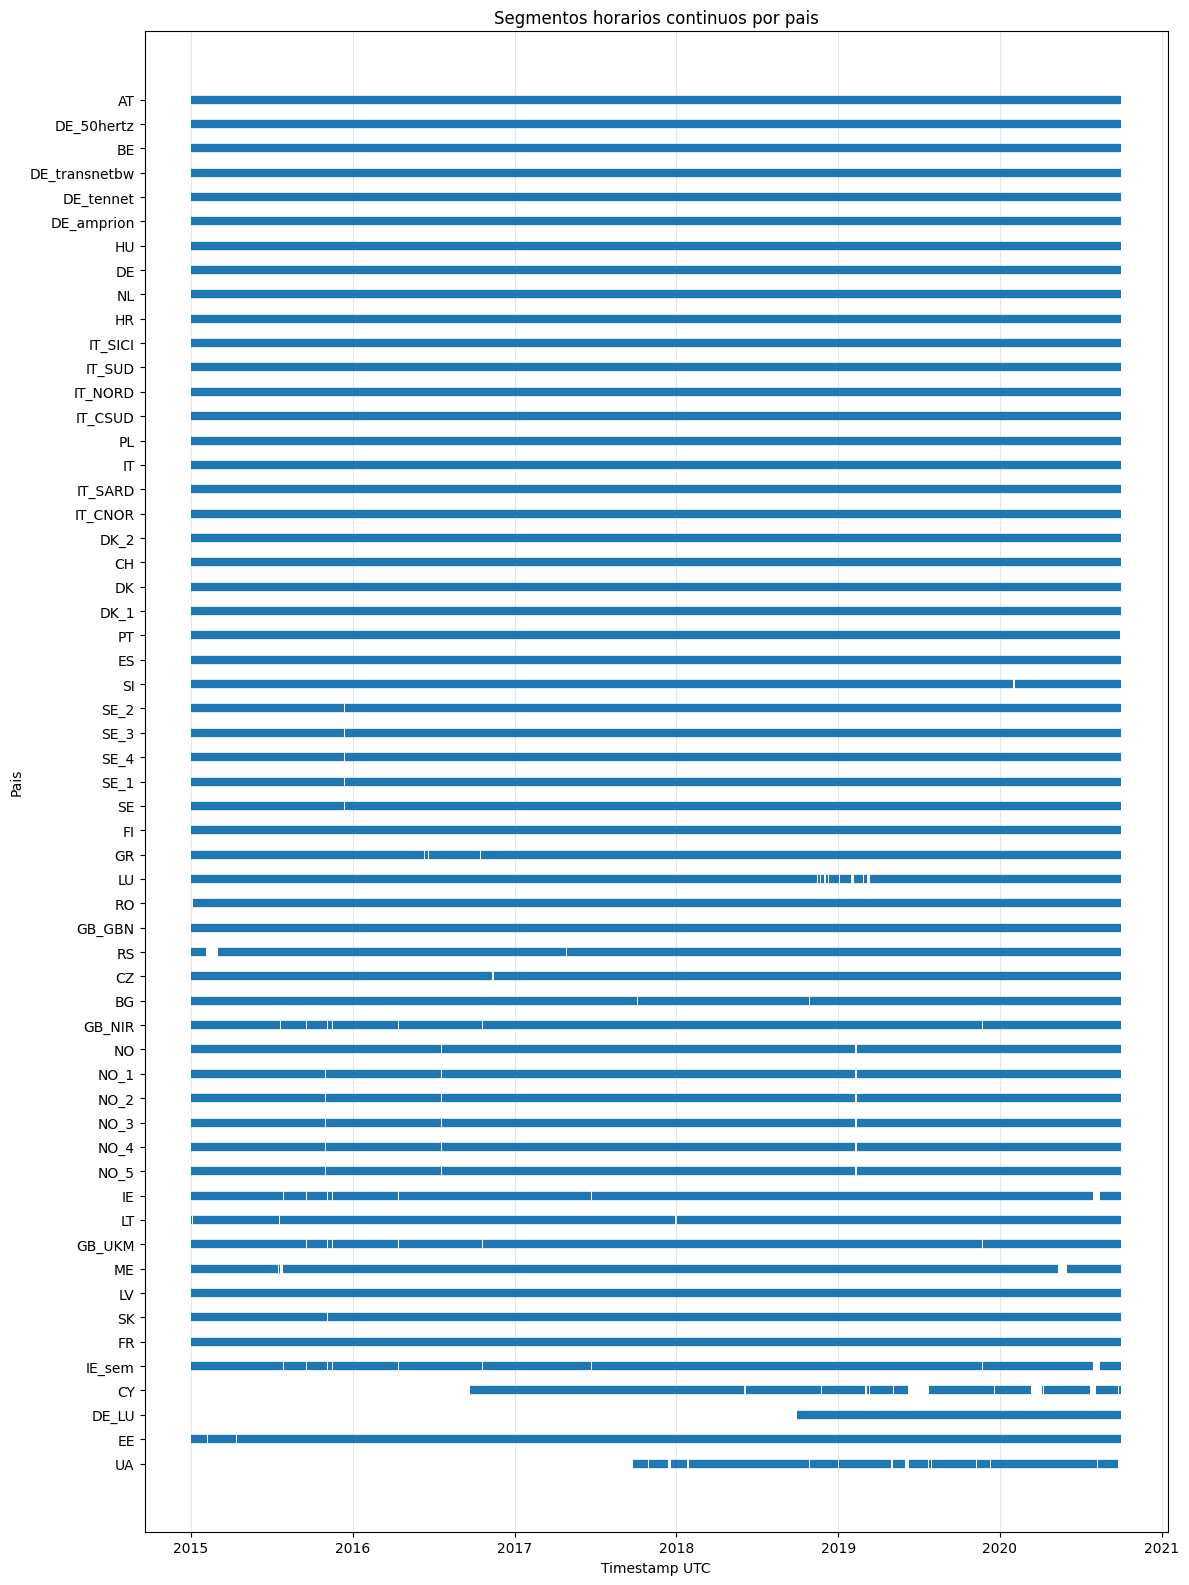

In [48]:
plot_countries = continuity_summary["country"].tolist()
country_positions = {country: idx for idx, country in enumerate(reversed(plot_countries))}

fig, ax = plt.subplots(figsize=(12, max(5, len(plot_countries) * 0.28)))

for row in segments.itertuples(index=False):
    ax.hlines(
        y=country_positions[row.country],
        xmin=row.start,
        xmax=row.end,
        linewidth=6,
    )

ax.set_yticks(list(country_positions.values()))
ax.set_yticklabels(list(country_positions.keys()))
ax.set_title("Segmentos horarios continuos por pais")
ax.set_xlabel("Timestamp UTC")
ax.set_ylabel("Pais")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Rango sugerido para exportar

La siguiente tabla toma el segmento continuo mas largo de cada pais. Estos valores se pueden usar como punto de partida para llamadas posteriores a `prepare_country_dataset(country, start, end)`.


In [49]:
export_candidates = continuity_summary[[
    "country",
    "longest_start",
    "longest_end",
    "longest_segment_hours",
    "segments",
]].copy()

export_candidates["start"] = export_candidates["longest_start"].dt.strftime("%Y-%m-%d %H:%M:%S%z")
export_candidates["end"] = export_candidates["longest_end"].dt.strftime("%Y-%m-%d %H:%M:%S%z")

display(export_candidates[["country", "start", "end", "longest_segment_hours", "segments"]])


,country,start,end,longest_segment_hours,segments
0,AT,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
1,DE_50hertz,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
2,BE,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
3,DE_transnetbw,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
4,DE_tennet,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
5,DE_amprion,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
6,HU,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
7,DE,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
8,NL,2015-01-01 00:00:00+0000,2020-09-30 23:00:00+0000,50400,1
9,HR,2015-01-01 01:00:00+0000,2020-09-30 22:00:00+0000,50398,1


## Exploracion visual de una serie

Se selecciona automaticamente el pais con el segmento continuo mas largo. Esta vista sirve solo para inspeccionar la forma general del bloque candidato.


In [50]:
COUNTRY = continuity_summary.iloc[0]["country"]
selected_segment = segments.loc[segments["country"].eq(COUNTRY)].sort_values("duration_hours", ascending=False).iloc[0]
country_column = f"{COUNTRY}{TARGET_SUFFIX}"

country_series = (
    df.loc[df["timestamp"].between(selected_segment["start"], selected_segment["end"]), ["timestamp", country_column]]
    .rename(columns={country_column: "y"})
)

display(selected_segment)
display(country_series.describe(include="all"))
display(country_series.head())
display(country_series.tail())


country                                           AT
column            AT_load_actual_entsoe_transparency
start                      2015-01-01 00:00:00+00:00
end                        2020-09-30 23:00:00+00:00
duration_hours                                 50400
Name: 0, dtype: object

,timestamp,y
count,50400,50400.000000
mean,2017-11-15 23:30:00+00:00,7070.148631
min,2015-01-01 00:00:00+00:00,664.000000
25%,2016-06-08 23:45:00+00:00,5941.000000
50%,2017-11-15 23:30:00+00:00,7032.000000
75%,2019-04-24 23:15:00+00:00,8079.000000
max,2020-09-30 23:00:00+00:00,10803.000000
std,NaN,1400.263167


,timestamp,y
1,2015-01-01 00:00:00+00:00,5946.0
2,2015-01-01 01:00:00+00:00,5726.0
3,2015-01-01 02:00:00+00:00,5347.0
4,2015-01-01 03:00:00+00:00,5249.0
5,2015-01-01 04:00:00+00:00,5309.0


,timestamp,y
50396,2020-09-30 19:00:00+00:00,6661.0
50397,2020-09-30 20:00:00+00:00,6336.0
50398,2020-09-30 21:00:00+00:00,5932.0
50399,2020-09-30 22:00:00+00:00,5628.0
50400,2020-09-30 23:00:00+00:00,5395.0


## Grafica de la serie seleccionada

Se grafica el segmento continuo mas largo del pais seleccionado para revisar visualmente la escala y el comportamiento general de la demanda.


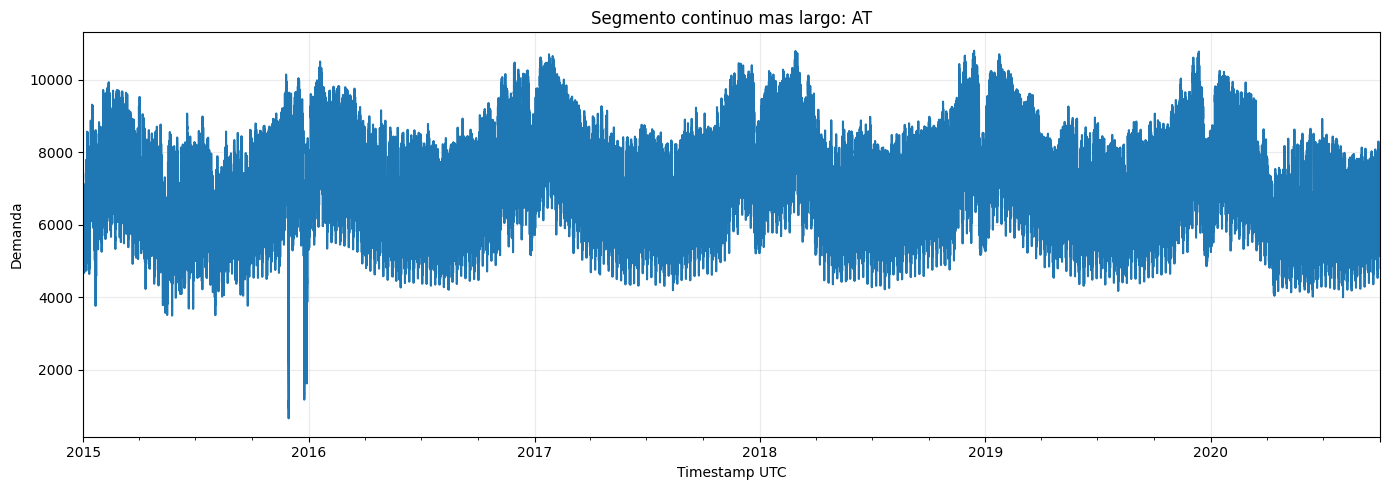

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))

country_series.plot(x="timestamp", y="y", ax=ax, legend=False)
ax.set_title(f"Segmento continuo mas largo: {COUNTRY}")
ax.set_ylabel("Demanda")
ax.set_xlabel("Timestamp UTC")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Verificación del contrato de salida

Se prepara una vista preliminar con las columnas esperadas por la aplicación. Esta celda no exporta archivos; solo confirma la forma que deberá producir la notebook de preparación.

In [52]:
preview_processed = country_series.dropna().copy()
preview_processed["timestamp"] = preview_processed["timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S%z")

display(preview_processed.head())
print(f"Columnas: {list(preview_processed.columns)}")
print(f"Filas sin nulos para {COUNTRY}: {len(preview_processed):,}")

,timestamp,y
1,2015-01-01 00:00:00+0000,5946.0
2,2015-01-01 01:00:00+0000,5726.0
3,2015-01-01 02:00:00+0000,5347.0
4,2015-01-01 03:00:00+0000,5249.0
5,2015-01-01 04:00:00+0000,5309.0


Columnas: ['timestamp', 'y']
Filas sin nulos para AT: 50,400
